<a href="https://colab.research.google.com/github/Kumud-Arora/CS4375-neural-networks/blob/main/neural_networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.neural_network import MLPClassifier

In [27]:
# Loading the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "class"
]

df = pd.read_csv(url, names=columns)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [28]:
# Preprocessing
def preprocessing(df):

  # Dropping any null or na values

  df = df.dropna()

  # Dropping any redundant values

  df = df.drop_duplicates()

  # Splitting the features and target

  # Features (all columns except the last):
  X = df.iloc[:, :-1]

  # Target (last column):
  Y = df.iloc[:, -1]

  # Convert categorical variables to numerical variables
  Y = pd.factorize(Y)[0]

  # Splitting the dataset into training and testing parts
  # Train/Test ratio is 80/20

  X_train, X_test, Y_train, Y_test = train_test_split(
      X,
      Y,
      test_size=0.2,
      random_state=1)

  # Standardizing the features using StandardScaler of sklearn
  scaler = StandardScaler()

  # Fit scaler only on training data to prevent data leakage
  X_train = scaler.fit_transform(X_train)

  # Apply the same transformation to test data
  X_test = scaler.transform(X_test)

  return X_train, X_test, Y_train, Y_test

X_train, X_test, Y_train, Y_test = preprocessing(df)

In [29]:
# Creating neural network function

def create_neural_network(hidden_layers, activation, learning_rate, epochs):

  # MlPClassifier implements feedforwards neural network
  model = MLPClassifier(
      # architecture of hidden structures
      hidden_layer_sizes=hidden_layers,
      activation=activation,
      learning_rate_init=learning_rate,
      max_iter=epochs,
      random_state=1
  )

  return model

In [30]:
# Neural network hyperparameters

# Evaluating multiple neural network configurations to figure out which combination gives the best performance

# activation functions to test
activations = ['logistic', 'tanh', 'relu']

# learning rates for gradient descent
learning_rates = [0.01, 0.1]

# number of training iterations
max_iterations = [100, 200] # also known as epochs

# hidden layer lists
hidden_layers_list = [(8,8), (8,8,8)]

Training:  logistic 0.01 100 (8, 8)
Training:  logistic 0.01 100 (8, 8, 8)
Training:  logistic 0.01 200 (8, 8)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Training:  logistic 0.01 200 (8, 8, 8)
Training:  logistic 0.1 100 (8, 8)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Training:  logistic 0.1 100 (8, 8, 8)
Training:  logistic 0.1 200 (8, 8)
Training:  logistic 0.1 200 (8, 8, 8)
Training:  tanh 0.01 100 (8, 8)


...

Training:  tanh 0.1 100 (8, 8)
Training:  tanh 0.1 100 (8, 8, 8)
Training:  tanh 0.1 200 (8, 8)
Training:  tanh 0.1 200 (8, 8, 8)
Training:  relu 0.01 100 (8, 8)
Training:  relu 0.01 100 (8, 8, 8)
Training:  relu 0.01 200 (8, 8)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Training:  relu 0.01 200 (8, 8, 8)
Training:  relu 0.1 100 (8, 8)
Training:  relu 0.1 100 (8, 8, 8)
Training:  relu 0.1 200 (8, 8)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Training:  relu 0.1 200 (8, 8, 8)


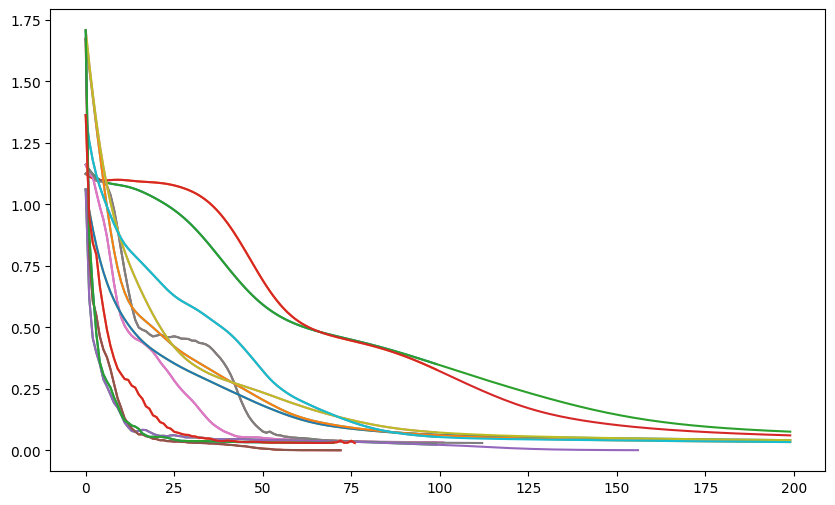

In [31]:
# Training loop
# Training the neural network for any combo of hyperparameters defined above. Performance of each model is saved for comparison

results =[]
histories = []

plt.figure(figsize=(10, 6))

# iterating through each hyperparameter combo
for activation in activations:
    for learning_rate in learning_rates:
        for max_iter in max_iterations:
          for layer in hidden_layers_list:
            print("Training: ", activation, learning_rate, max_iter, layer)

            # create a model with these hyperparementers
            model = create_neural_network(layer, activation, learning_rate, max_iter)

            # Train the neural network
            model.fit(X_train, Y_train)

            # Predictions
            train_predictions = model.predict(X_train)
            test_predictions = model.predict(X_test)

            # Metrics

            # Accuracy
            train_accuracy = accuracy_score(Y_train, train_predictions)
            test_accuracy = accuracy_score(Y_test, test_predictions)


            # Mean squared error
            train_mse = mean_squared_error(Y_train, train_predictions)
            test_mse = mean_squared_error(Y_test, test_predictions)

            # saving results
            results.append([
                    activation,
                    learning_rate,
                    max_iter,
                    layer,
                    train_accuracy,
                    test_accuracy,
                    train_mse,
                    test_mse
                ])

            # plot training loss curve
            plt.plot(model.loss_curve_, label=f'{activation} {learning_rate} {max_iter} {layer}')


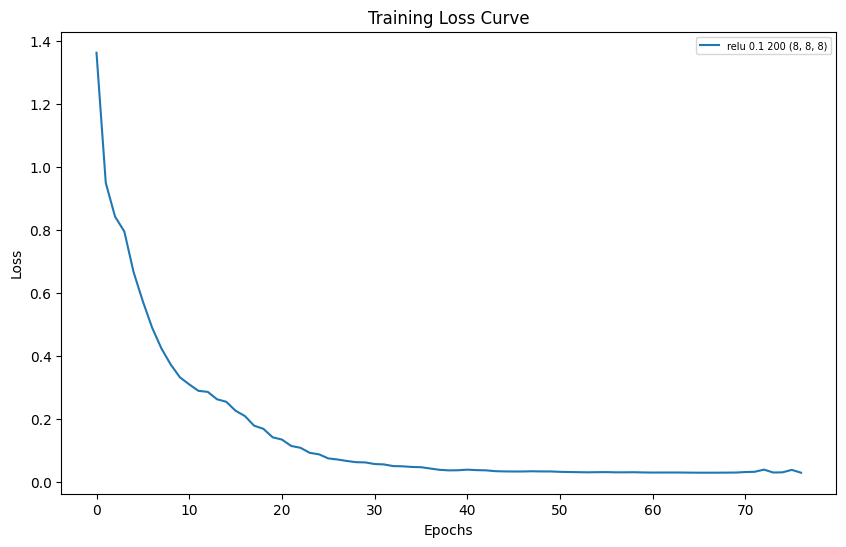

In [41]:
# Model history plot- shows how the training loss changes over the number of epochs for each model.

plt.figure(figsize=(10,6))


if hasattr(model, 'loss_curve_') and len(model.loss_curve_) > 0:
    plt.plot(model.loss_curve_, label=f'{activation} {learning_rate} {max_iter} {layer}')
else:
    print(f"No loss curve for model with {activation} {learning_rate} {max_iter} {layer}")

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend(fontsize=7)
plt.show()

In [42]:
# Results table

columns = ['Activation',
           'Learning Rate',
           'Max Iterations',
           'Hidden Layers',
           'Train Accuracy',
           'Test Accuracy',
           'Train MSE',
           'Test MSE']

results_df = pd.DataFrame(results, columns=columns)
results_df

,Activation,Learning Rate,Max Iterations,Hidden Layers,Train Accuracy,Test Accuracy,Train MSE,Test MSE
0,logistic,0.01,100,"(8, 8)",0.923077,0.833333,0.076923,0.166667
1,logistic,0.01,100,"(8, 8, 8)",0.931624,0.866667,0.068376,0.133333
2,logistic,0.01,200,"(8, 8)",0.974359,0.966667,0.025641,0.033333
3,logistic,0.01,200,"(8, 8, 8)",0.982906,0.933333,0.017094,0.066667
4,logistic,0.10,100,"(8, 8)",0.991453,0.933333,0.008547,0.066667
5,logistic,0.10,100,"(8, 8, 8)",0.991453,0.933333,0.008547,0.066667
6,logistic,0.10,200,"(8, 8)",0.991453,0.933333,0.008547,0.066667
7,logistic,0.10,200,"(8, 8, 8)",0.991453,0.933333,0.008547,0.066667
8,tanh,0.01,100,"(8, 8)",0.974359,0.966667,0.025641,0.033333
9,tanh,0.01,100,"(8, 8, 8)",0.982906,0.933333,0.017094,0.066667
